<a href="https://colab.research.google.com/github/msmareeb/databases-and-analytics-assignment/blob/main/database_assignemnt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
install.packages("sqldf")
install.packages("dplyr")
install.packages("ggplot2")
install.packages("readr")

library(sqldf)
library(dplyr)
library(ggplot2)
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
list.files("datasets")


character(0)

In [4]:
customers <- read_csv("/content/customers.csv")
app_events <- read.csv("/content/app_events.csv")
complaints <- read.csv("/content/complaints.csv")
data_dictionary <- read.csv("/content/data_dictionary.csv")
deliveries <- read.csv("/content/deliveries.csv")
drivers <- read.csv("/content/drivers.csv")
hubs <- read.csv("/content/hubs.csv")
incidents <- read.csv("/content/incidents.csv")
orders <- read.csv("/content/orders.csv")
vehicles <- read.csv("/content/vehicles.csv")

Rows: 650 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (5): customer_id, home_zone, customer_type, preferred_channel, account_...
dbl  (3): age, loyalty_score, app_engagement_score
dttm (1): signup_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
str(customers)

spc_tbl_ [650 × 9] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ customer_id         : chr [1:650] "C0001" "C0002" "C0003" "C0004" ...
 $ age                 : num [1:650] 26 61 66 75 26 41 54 70 34 23 ...
 $ home_zone           : chr [1:650] "North" "AIRPORT" "East" "CENTRAL" ...
 $ customer_type       : chr [1:650] "SME" "Consumer" "Consumer" "Consumer" ...
 $ signup_date         : POSIXct[1:650], format: "2024-11-27 04:25:00" "2025-10-28 01:04:00" ...
 $ loyalty_score       : num [1:650] 44.9 55.4 75.9 32.5 55.9 39.9 36.1 84.6 62.6 87.2 ...
 $ app_engagement_score: num [1:650] 69.2 66.6 33.8 33 100 43.3 39 65.2 40.8 48.6 ...
 $ preferred_channel   : chr [1:650] "App" "App" NA "App" ...
 $ account_status      : chr [1:650] "Active" "Active" "Active" "Active" ...
 - attr(*, "spec")=
  .. cols(
  ..   customer_id = col_character(),
  ..   age = col_double(),
  ..   home_zone = col_character(),
  ..   customer_type = col_character(),
  ..   signup_date = col_datetime(format = ""),
  ..   l

In [ ]:
head(customers)


customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NA,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


In [ ]:
late_deliveries <- sqldf("
SELECT delivery_status, COUNT(*) as total
FROM deliveries
GROUP BY delivery_status
")

print(late_deliveries)

  delivery_status total
1         Delayed   202
2          Failed   132
3          OnTime   616


The analysis shows that delayed and failed deliveries represent a significant portion of operations, indicating service reliability issues within the organisation.

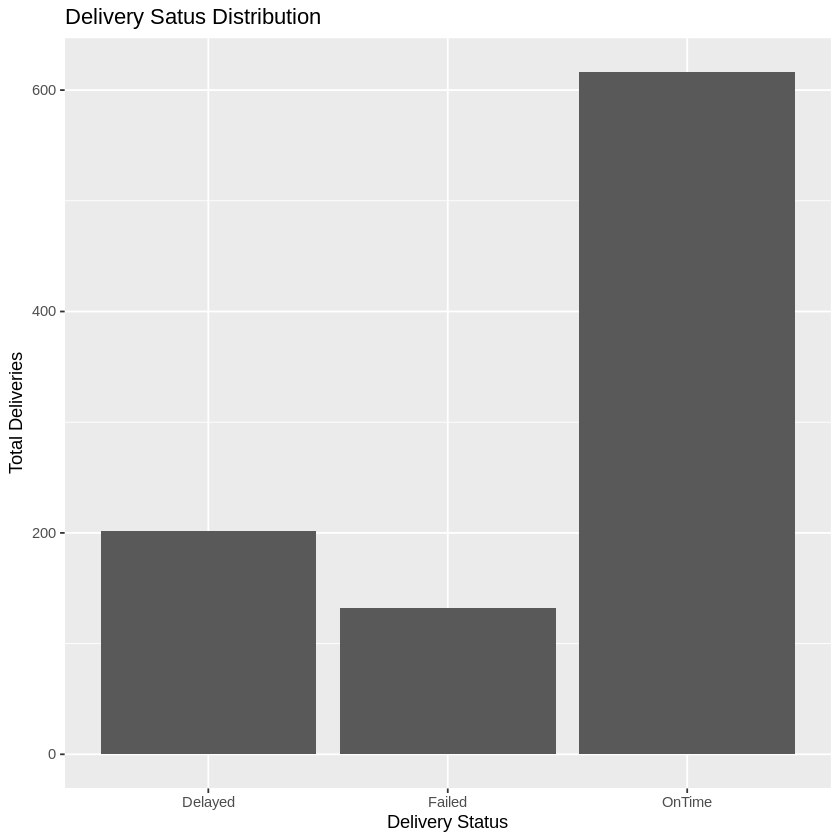

In [ ]:
ggplot(late_deliveries,aes(x = delivery_status, y = total)) +
  geom_bar(stat = "identity") +
  labs(
  title = "Delivery Satus Distribution",
  x= "Delivery Status",
  y = "Total Deliveries"
  )

In [ ]:
complaint_analysis <- sqldf("
SELECT complaint_type, COUNT(*) as total_complaints
FROM complaints
GROUP BY complaint_type
ORDER BY total_complaints DESC
")

print(complaint_analysis)

     complaint_type total_complaints
1             Delay              101
2      MissedPickup               64
3          AppIssue               53
4   DriverBehaviour               51
5 SupportExperience               20
6           Billing               16
7            Damage               15


Late delivery and driver behaviour complaints appear most frequently, suggesting operational inefficiencies and customer dissatisfaction.

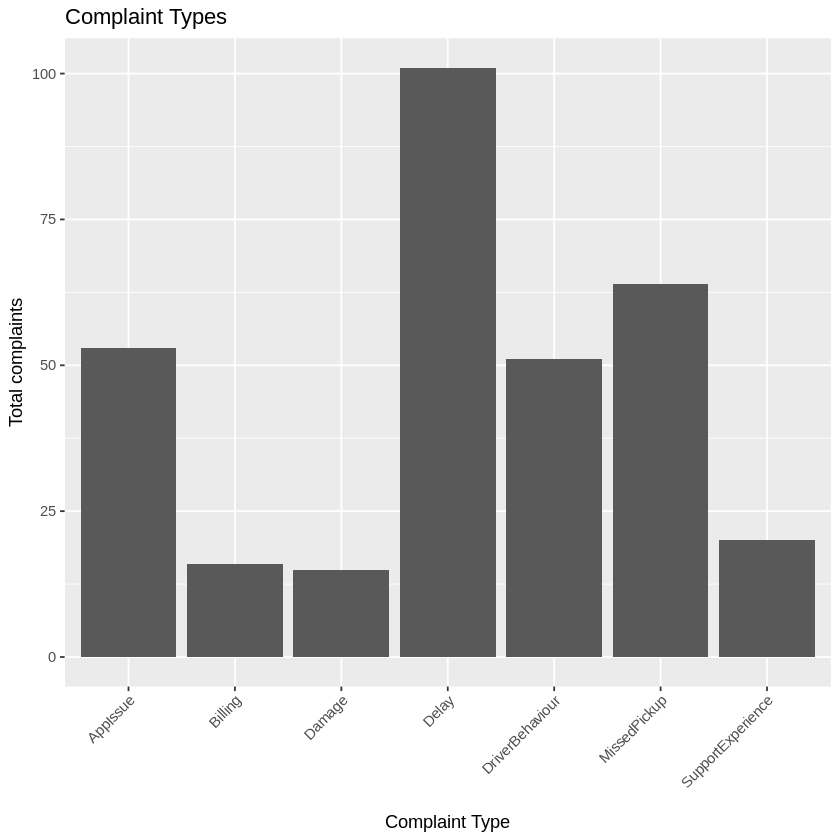

In [ ]:
ggplot(complaint_analysis,
       aes(x = complaint_type,
           y = total_complaints)) +
  geom_bar(stat = "identity") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title = "Complaint Types",
    x = "Complaint Type",
    y = "Total complaints"
  )

In [5]:
zone_failures <- sqldf("
SELECT
    o.dropoff_zone,
    COUNT(*) AS failed_deliveries
FROM orders o
JOIN deliveries d
ON o.order_id = d.order_id
WHERE d.delivery_status = 'Failed'
GROUP BY o.dropoff_zone
ORDER BY failed_deliveries DESC
")

print(zone_failures)

   dropoff_zone failed_deliveries
1         SOUTH                11
2     RiverSide                11
3       Central                11
4         north                10
5          West                10
6         North                 9
7     Riverside                 8
8          EAST                 8
9          WEST                 7
10        South                 7
11          Ctr                 7
12      CENTRAL                 7
13      Airport                 7
14      AIRPORT                 7
15        NORTH                 6
16         East                 6


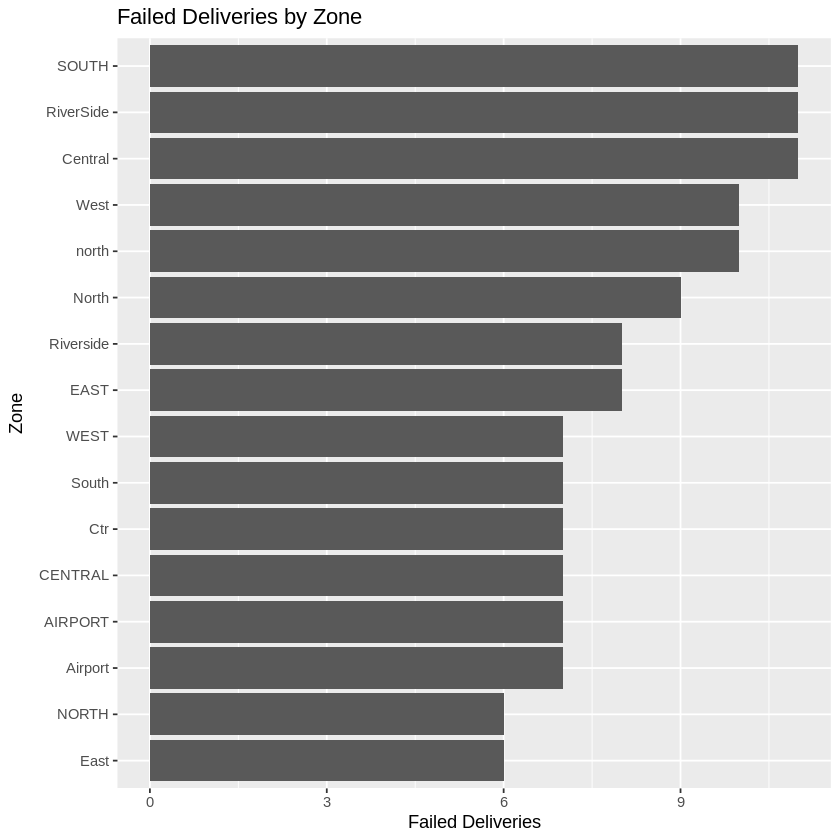

In [6]:
ggplot(zone_failures,
       aes(x = reorder(dropoff_zone, failed_deliveries),
           y = failed_deliveries)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Failed Deliveries by Zone",
    x = "Zone",
    y = "Failed Deliveries"
  )

Certain operational zones experience significantly **higher failed delivery rates** than others, indicating possible route inefficiencies, poor resource allocation, or operational bottlenecks within those regions.

In [7]:
complaint_severity <- sqldf("
SELECT
    severity,
    COUNT(*) AS total_cases
FROM complaints
GROUP BY severity
ORDER BY total_cases DESC
")

print(complaint_severity)

  severity total_cases
1   Medium         172
2     High          77
3      Low          71


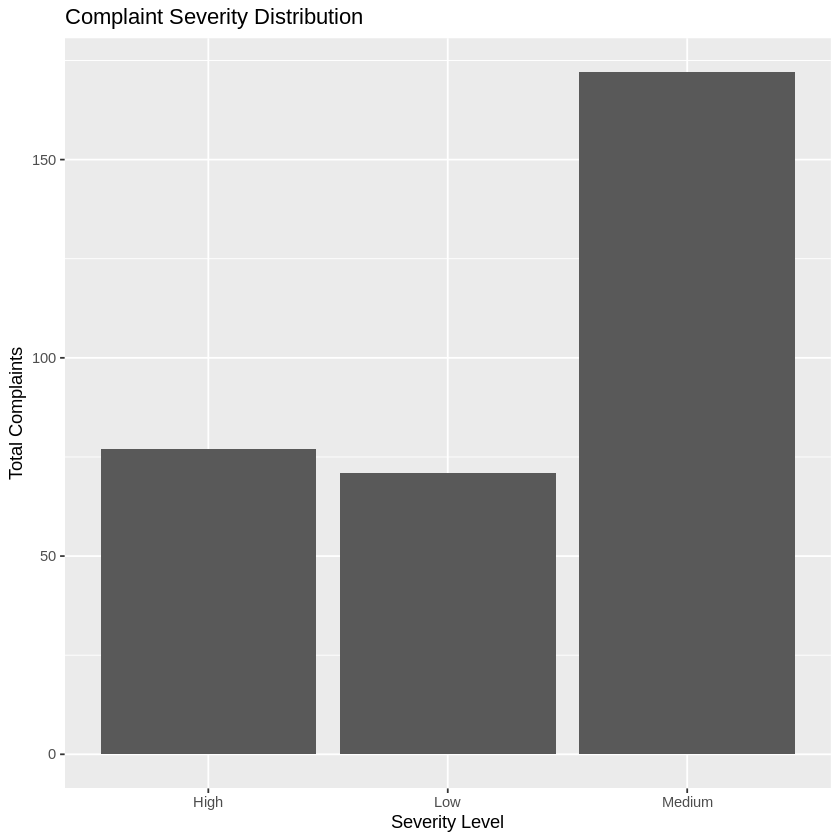

In [8]:
ggplot(complaint_severity,
       aes(x = severity,
           y = total_cases)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaint Severity Distribution",
    x = "Severity Level",
    y = "Total Complaints"
  )

High-severity complaints represent serious service failures and may indicate weaknesses in delivery reliability, customer communication, or driver performance.

In [10]:
colnames(drivers)

[1] "driver_id"        "base_zone"        "employment_type"  "years_experience"
[5] "training_score"   "driver_rating"    "shift_preference" "active_flag"

In [11]:
driver_complaints <- sqldf("
SELECT
    d.driver_id,
    dr.base_zone,
    dr.training_score,
    dr.driver_rating,
    COUNT(c.complaint_id) AS complaint_count
FROM deliveries d
JOIN drivers dr
ON d.driver_id = dr.driver_id
LEFT JOIN complaints c
ON d.order_id = c.order_id
GROUP BY d.driver_id
ORDER BY complaint_count DESC
")

print(driver_complaints)

    driver_id base_zone training_score driver_rating complaint_count
1        D133     South           88.2          3.99               6
2        D164   Central           76.1          4.07               5
3        D165     North           82.2          3.89               4
4        D160      East           72.8          4.48               4
5        D150      EAST           88.1          4.08               4
6        D119     South           56.0          3.55               4
7        D087     north           73.3          4.43               4
8        D068   Central           83.9          3.99               4
9        D024 RiverSide           71.4          3.35               4
10       D155   CENTRAL           69.5          3.98               3
11       D146   Airport             NA          4.36               3
12       D126      East           69.7          4.10               3
13       D117     north           71.1          3.93               3
14       D105 RiverSide           

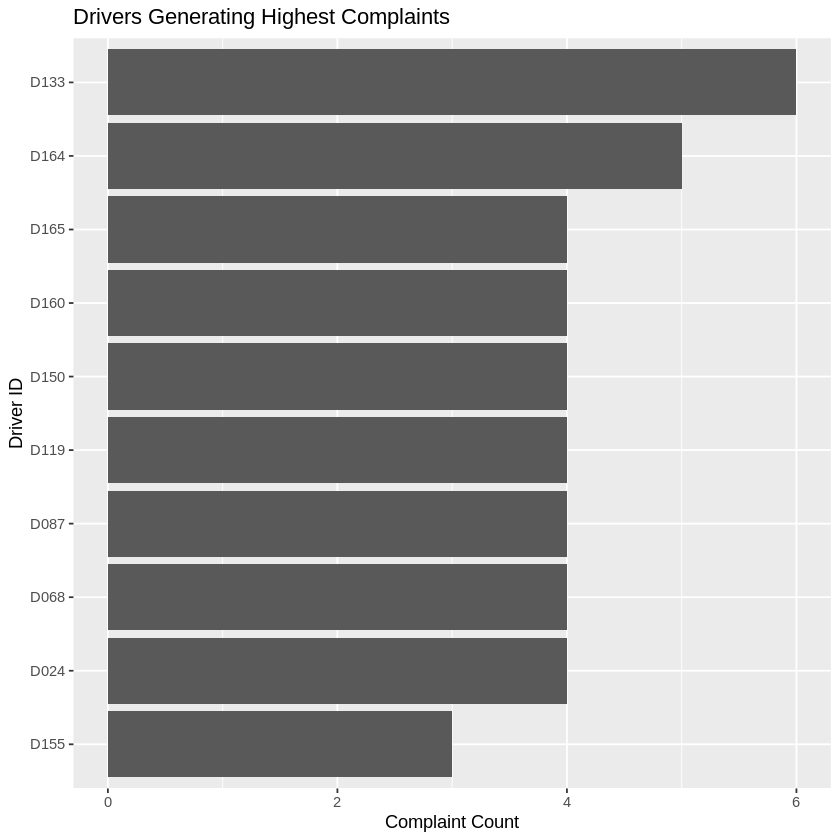

In [12]:
top_drivers <- head(driver_complaints, 10)

ggplot(top_drivers,
       aes(x = reorder(driver_id, complaint_count),
           y = complaint_count)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Drivers Generating Highest Complaints",
    x = "Driver ID",
    y = "Complaint Count"
  )

The analysis identified several drivers with significantly higher complaint counts than others. Driver D133 recorded the highest complaint frequency, followed by drivers D164 and D165. This suggests that customer dissatisfaction may not be evenly distributed across the workforce.

In [13]:
colnames(customers)
colnames(orders)
colnames(deliveries)
colnames(complaints)
colnames(vehicles)
colnames(incidents)
colnames(hubs)
colnames(app_events)

[1] "customer_id"          "age"                  "home_zone"           
[4] "customer_type"        "signup_date"          "loyalty_score"       
[7] "app_engagement_score" "preferred_channel"    "account_status"

[1] "order_id"              "customer_id"           "service_type"         
 [4] "order_created_at"      "promised_window_hours" "pickup_zone"          
 [7] "dropoff_zone"          "priority_level"        "order_value"          
[10] "booking_channel"       "special_handling_flag"

[1] "delivery_id"                   "order_id"                     
 [3] "driver_id"                     "vehicle_id"                   
 [5] "hub_id"                        "dispatch_time"                
 [7] "delivery_completed_at"         "delivery_status"              
 [9] "route_distance_km"             "manual_route_override_count"  
[11] "proof_of_completion_missing"   "customer_rating_post_delivery"
[13] "fuel_or_charge_cost"

[1] "complaint_id"        "customer_id"         "order_id"           
 [4] "complaint_type"      "channel"             "severity"           
 [7] "created_at"          "status"              "resolution_days"    
[10] "compensation_amount"

[1] "vehicle_id"         "vehicle_type"       "assigned_zone"     
[4] "commission_date"    "battery_health_pct" "odometer_km"       
[7] "maintenance_status" "telematics_version"

[1] "incident_id"       "delivery_id"       "incident_type"    
[4] "reported_at"       "severity"          "resolution_status"
[7] "resolved_hours"

[1] "hub_id"         "hub_name"       "zone"           "hub_type"      
[5] "capacity_score"

[1] "event_id"        "customer_id"     "order_id"        "event_timestamp"
 [5] "event_type"      "session_id"      "device_type"     "zone_context"   
 [9] "api_latency_ms"  "success_flag"

In [14]:
delivery_complaints <- sqldf("
SELECT
    d.delivery_status,
    COUNT(c.complaint_id) AS complaint_count
FROM deliveries d
LEFT JOIN complaints c
ON d.order_id = c.order_id
GROUP BY d.delivery_status
ORDER BY complaint_count DESC
")

print(delivery_complaints)

  delivery_status complaint_count
1          OnTime             149
2         Delayed              48
3          Failed              35


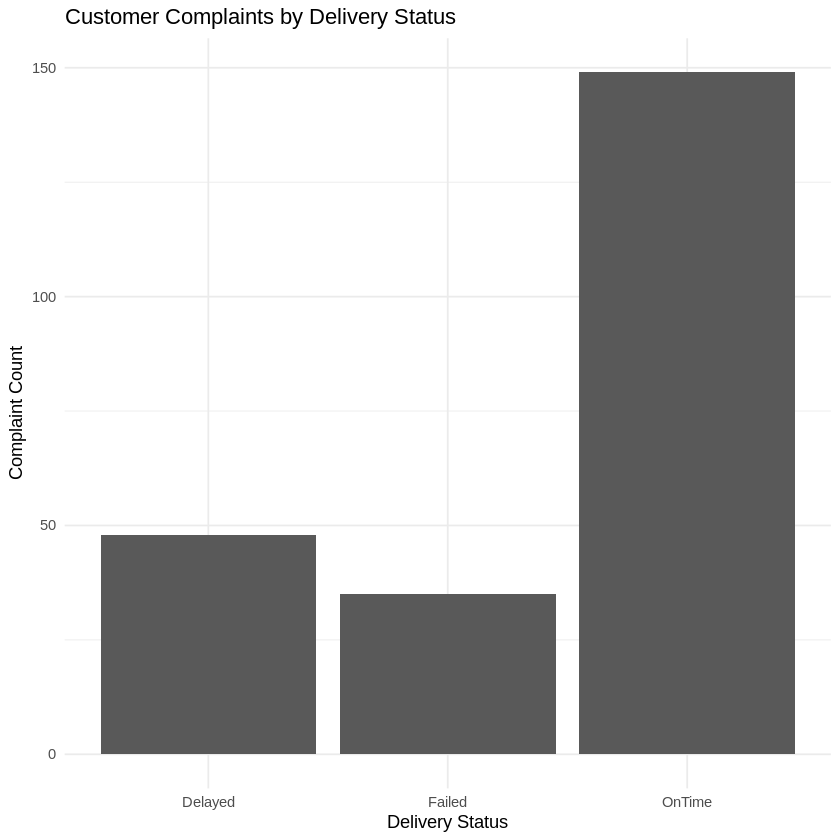

In [15]:
ggplot(delivery_complaints,
       aes(x = delivery_status,
           y = complaint_count)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Customer Complaints by Delivery Status",
    x = "Delivery Status",
    y = "Complaint Count"
  ) +
  theme_minimal()

This suggests that customer dissatisfaction is influenced by factors beyond delivery timing alone. Potential contributing issues may include driver behaviour, communication quality, proof-of-completion failures, damaged goods, platform usability issues, or inconsistencies between operational records and customer expectations.

In [16]:
ontime_complaints <- sqldf("
SELECT
    c.complaint_type,
    COUNT(*) AS total
FROM complaints c
JOIN deliveries d
ON c.order_id = d.order_id
WHERE d.delivery_status = 'OnTime'
GROUP BY c.complaint_type
ORDER BY total DESC
")

print(ontime_complaints)

     complaint_type total
1             Delay    44
2   DriverBehaviour    29
3      MissedPickup    25
4          AppIssue    25
5 SupportExperience    11
6            Damage     8
7           Billing     7


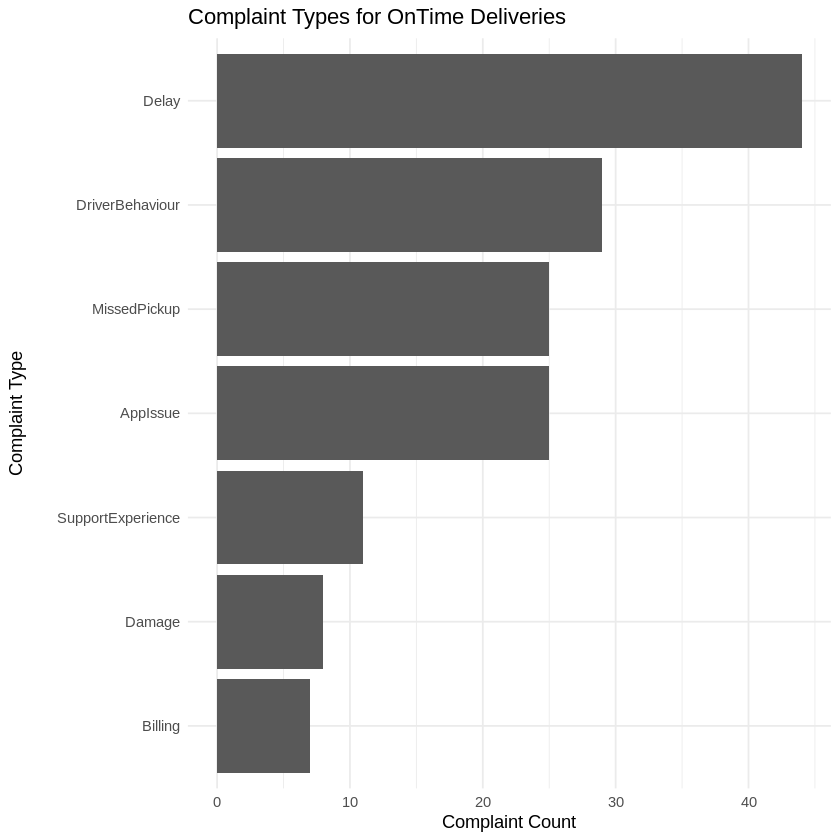

In [17]:
ggplot(ontime_complaints,
       aes(x = reorder(complaint_type, total),
           y = total)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(
    title = "Complaint Types for OnTime Deliveries",
    x = "Complaint Type",
    y = "Complaint Count"
  ) +
  theme_minimal()

Further analysis of complaints linked to deliveries classified as “OnTime” revealed that customer dissatisfaction was not driven solely by delivery delays. The most common complaint categories included delay-related issues, driver behaviour concerns, missed pickups, and mobile application problems.

In [18]:
route_analysis <- sqldf("
SELECT
    manual_route_override_count,
    AVG(customer_rating_post_delivery) AS avg_rating,
    COUNT(*) AS total_deliveries
FROM deliveries
GROUP BY manual_route_override_count
ORDER BY manual_route_override_count
")

print(route_analysis)

  manual_route_override_count avg_rating total_deliveries
1                           0   3.900816              399
2                           1   3.884463              310
3                           2   3.824600              153
4                           3   3.668393               57
5                           4   3.865652               23
6                           5   3.378571                7
7                           7   4.010000                1


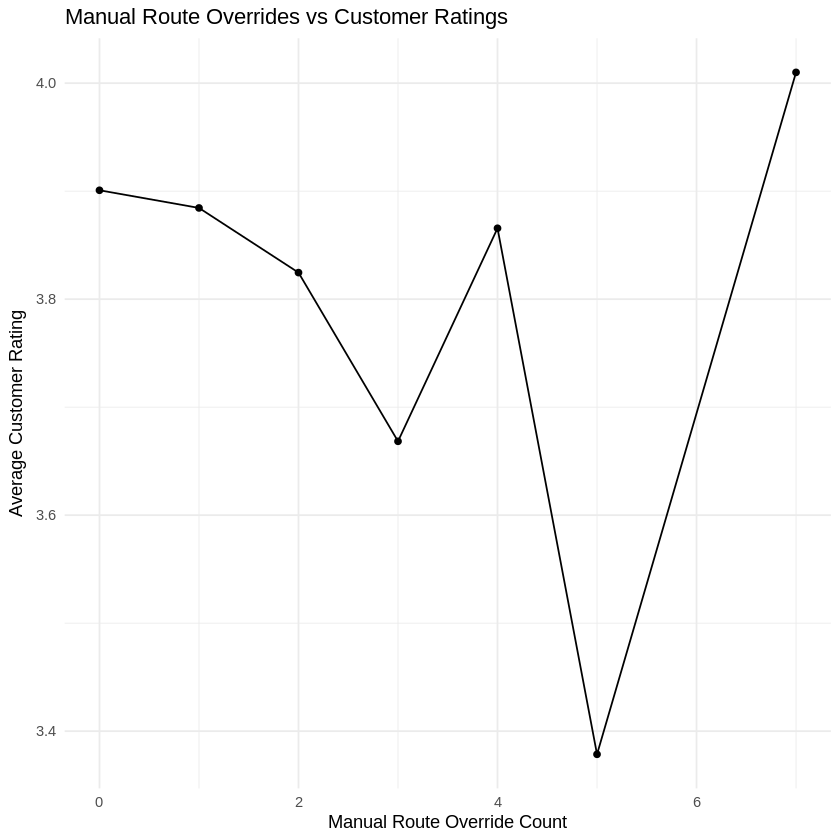

In [19]:
ggplot(route_analysis,
       aes(x = manual_route_override_count,
           y = avg_rating)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Manual Route Overrides vs Customer Ratings",
    x = "Manual Route Override Count",
    y = "Average Customer Rating"
  ) +
  theme_minimal()

The analysis identified a general decline in customer ratings as the number of manual route overrides increased. Deliveries with no route overrides achieved an average rating of approximately 3.90, while deliveries involving multiple overrides showed progressively lower customer satisfaction scores.